<a href="https://colab.research.google.com/github/RonaldoLopezTucux/ASR/blob/main/canary_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install dependencies

In [1]:
!pip install -q nvidia-riva-client soundfile requests pandas huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.67.1 which is incompatible.


## 2. API keys
Store both as Colab Secrets (🔑 icon) and enable notebook access.

In [2]:
from google.colab import userdata

NVIDIA_API_KEY = userdata.get("NVIDIA_API_KEY")
HF_TOKEN       = userdata.get("HF_TOKEN")

## 3. Connect to Canary-1B NIM

In [3]:
import riva.client

auth = riva.client.Auth(
    use_ssl=True,
    uri="grpc.nvcf.nvidia.com:443",
    metadata_args=[
        ["function-id", "b0e8b4a5-217c-40b7-9b96-17d84e666317"],
        ["authorization", f"Bearer {NVIDIA_API_KEY}"]
    ]
)

asr_client = riva.client.ASRService(auth)

config = riva.client.RecognitionConfig(
    language_code="en-US",
    max_alternatives=1,
    enable_automatic_punctuation=False,
)

print("Connected.")

Connected.


## 4. Discover all interviews and speakers from the txt folder

In [4]:
import requests
import pandas as pd

REPO_ID  = "zsayers/CORAAL"
HF_HEADERS = {"Authorization": f"Bearer {HF_TOKEN}"}

# Get all .txt files in the txt/ folder
api_url = f"https://huggingface.co/api/datasets/{REPO_ID}/tree/main/txt"
resp = requests.get(api_url, headers=HF_HEADERS)
resp.raise_for_status()

# Each filename stem is an interview ID, e.g. "ATL_se0_ag1_f_01_1"
interview_ids = [
    item["path"].split("/")[-1].replace(".txt", "")
    for item in resp.json()
    if item["path"].endswith(".txt")
]

print(f"{len(interview_ids)} interviews found")
print(interview_ids[:5])

271 interviews found
['ATL_se0_ag1_f_01_1', 'ATL_se0_ag1_f_02_1', 'ATL_se0_ag1_f_03_1', 'ATL_se0_ag1_m_01_1', 'ATL_se0_ag1_m_02_1']


## 5. Load all transcripts and match against available audio segments

In [7]:
import re

RAW_BASE_TMPL = "https://huggingface.co/datasets/{repo}/resolve/main/audiosegments/{iid}_segments"
TXT_URL_TMPL  = "https://huggingface.co/datasets/{repo}/resolve/main/txt/{iid}.txt"

def get_audio_files_for_interview(interview_id):
    """Return set of wav filenames available on HF for this interview."""
    api_url = (
        f"https://huggingface.co/api/datasets/{REPO_ID}/tree/main"
        f"/audiosegments/{interview_id}_segments"
    )
    resp = requests.get(api_url, headers=HF_HEADERS)
    if resp.status_code != 200:
        return set()
    return {item["path"].split("/")[-1] for item in resp.json() if item["path"].endswith(".wav")}

all_rows = []

for iid in interview_ids[:8]:
    txt_url = TXT_URL_TMPL.format(repo=REPO_ID, iid=iid)

    # Load transcript
    try:
        df_txt = pd.read_csv(txt_url, sep="\t")
    except Exception as e:
        print(f"  Skipping {iid}: {e}")
        continue

    # Build expected wav filename per row
    df_txt["wav_file"] = (
        df_txt["Spkr"].astype(str) + "_1_" +
        df_txt["StTime"].astype(str) + "_" +
        df_txt["EnTime"].astype(str) + ".wav"
    )

    # Get available audio files for this interview
    available = get_audio_files_for_interview(iid)
    if not available:
        print(f"  No audio found for {iid}, skipping")
        continue

    # Filter: audio must exist + no annotation symbols in transcript
    df_txt = df_txt[df_txt["wav_file"].isin(available)].copy()
    df_txt = df_txt[
        ~df_txt["Content"].astype(str).str.contains(
            r"[\(\)\[\]<>]|\/[^\/]+\/", regex=True
        )
    ].copy()

    if df_txt.empty:
        continue

    df_txt["interview_id"] = iid
    df_txt["raw_base"]     = RAW_BASE_TMPL.format(repo=REPO_ID, iid=iid)

    all_rows.append(df_txt[["interview_id", "Spkr", "wav_file", "Content", "raw_base"]])
    print(f"  {iid}: {len(df_txt)} clean utterances from {df_txt['Spkr'].nunique()} speaker(s)")

df_all = pd.concat(all_rows, ignore_index=True).rename(columns={"Content": "real_data"})
df_all["Canary_response"] = ""

print(f"\nTotal: {len(df_all)} utterances across {df_all['Spkr'].nunique()} unique speakers")
df_all.head()

  ATL_se0_ag1_f_01_1: 187 clean utterances from 1 speaker(s)
  ATL_se0_ag1_f_02_1: 292 clean utterances from 1 speaker(s)
  ATL_se0_ag1_f_03_1: 228 clean utterances from 1 speaker(s)
  ATL_se0_ag1_m_01_1: 316 clean utterances from 1 speaker(s)
  ATL_se0_ag1_m_02_1: 299 clean utterances from 1 speaker(s)
  ATL_se0_ag1_m_03_1: 231 clean utterances from 1 speaker(s)
  ATL_se0_ag1_m_04_1: 114 clean utterances from 1 speaker(s)

Total: 1667 utterances across 7 unique speakers


,interview_id,Spkr,wav_file,real_data,raw_base,Canary_response
0,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_0.4436_2.4068.wav,"They talking about, don't send him to his daddy.",https://huggingface.co/datasets/zsayers/CORAAL...,
1,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_2.6829_4.9538.wav,You just need to go file for child support.,https://huggingface.co/datasets/zsayers/CORAAL...,
2,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_6.0026_6.3944.wav,Why?,https://huggingface.co/datasets/zsayers/CORAAL...,
3,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_18.6134_20.0219.wav,"I'm a girl, I think.",https://huggingface.co/datasets/zsayers/CORAAL...,
4,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_25.4923_28.085.wav,"Hum, I'm supposed to say, black or non-hispanic.",https://huggingface.co/datasets/zsayers/CORAAL...,


## 6. Run Canary-1B inference on all utterances

In [8]:
import io, soundfile as sf

def transcribe_url(wav_url: str) -> str:
    """Download wav from HF and transcribe via Canary NIM."""
    r = requests.get(wav_url, headers=HF_HEADERS)
    r.raise_for_status()

    audio, sr = sf.read(io.BytesIO(r.content))
    if audio.ndim > 1:
        audio = audio.mean(axis=1)  # stereo -> mono
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV", subtype="PCM_16")

    response = asr_client.offline_recognize(buf.getvalue(), config)
    if response.results and response.results[0].alternatives:
        return response.results[0].alternatives[0].transcript
    return ""

total = len(df_all)

for idx, row in df_all.iterrows():
    url = f"{row['raw_base']}/{row['wav_file']}"
    df_all.loc[idx, "Canary_response"] = transcribe_url(url)

    if idx % 50 == 0:
        print(f"[{idx}/{total}] {row['Spkr']} | {row['wav_file']} → {df_all.loc[idx, 'Canary_response'][:60]}")

print("Done!")

[0/1667] ATL_se0_ag1_f_01 | ATL_se0_ag1_f_01_1_0.4436_2.4068.wav → they tell me don't send him to his daddy 
[50/1667] ATL_se0_ag1_f_01 | ATL_se0_ag1_f_01_1_400.554_401.7698.wav → school was 
[100/1667] ATL_se0_ag1_f_01 | ATL_se0_ag1_f_01_1_644.5014_645.7033.wav → the do they math work 
[150/1667] ATL_se0_ag1_f_01 | ATL_se0_ag1_f_01_1_1524.819_1525.635.wav → you know what 
[200/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_162.9995_163.613.wav → um 
[250/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_1122.8639_1123.4208.wav → but the trees 
[300/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_1322.1703_1322.8664.wav → yes 
[350/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_1529.3491_1530.9791.wav → so when i first moved down here 
[400/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_1745.4526_1746.195.wav → we did that 
[450/1667] ATL_se0_ag1_f_02 | ATL_se0_ag1_f_02_1_1925.9952_1926.3324.wav → and 
[500/1667] ATL_se0_ag1_f_03 | ATL_se0_ag1_f_03_1_204.4969_205.2102.wav → um 
[550/1667] ATL_se0_ag1_f_0

## 7. Compute WER per utterance and per speaker

In [9]:
def normalize(text):
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", str(text).lower())).strip()

def wer_counts(ref, hyp):
    r, h = ref.split(), hyp.split()
    dp = [[0] * (len(h)+1) for _ in range(len(r)+1)]
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            cost = 0 if r[i-1] == h[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    edits = dp[len(r)][len(h)]
    n = len(r)
    return edits, n, edits/n if n > 0 else 0.0

df_all["real_data_norm"]       = df_all["real_data"].map(normalize)
df_all["Canary_response_norm"] = df_all["Canary_response"].map(normalize)

df_all[["edits", "ref_words", "utt_wer"]] = df_all.apply(
    lambda row: pd.Series(wer_counts(row["real_data_norm"], row["Canary_response_norm"])),
    axis=1
)

# Per-speaker WER (corpus-level: sum edits / sum ref words)
df_speaker_wer = (
    df_all.groupby("Spkr")
    .apply(lambda g: pd.Series({
        "interview_id":  g["interview_id"].iloc[0],
        "n_utterances":  len(g),
        "total_edits":   g["edits"].sum(),
        "total_words":   g["ref_words"].sum(),
        "wer":           g["edits"].sum() / g["ref_words"].sum() if g["ref_words"].sum() > 0 else 0.0
    }))
    .reset_index()
    .sort_values("wer")
)

corpus_wer = df_all["edits"].sum() / df_all["ref_words"].sum()
print(f"Overall corpus WER: {corpus_wer:.4f} ({corpus_wer*100:.2f}%)")
print(f"\nPer-speaker WER:")
print(df_speaker_wer.to_string(index=False))

Overall corpus WER: 0.1651 (16.51%)

Per-speaker WER:
            Spkr       interview_id  n_utterances  total_edits  total_words      wer
ATL_se0_ag1_f_03 ATL_se0_ag1_f_03_1           228        164.0       1544.0 0.106218
ATL_se0_ag1_f_02 ATL_se0_ag1_f_02_1           292        229.0       1800.0 0.127222
ATL_se0_ag1_m_03 ATL_se0_ag1_m_03_1           231        177.0       1275.0 0.138824
ATL_se0_ag1_m_02 ATL_se0_ag1_m_02_1           299        226.0       1533.0 0.147423
ATL_se0_ag1_m_04 ATL_se0_ag1_m_04_1           114        156.0        925.0 0.168649
ATL_se0_ag1_f_01 ATL_se0_ag1_f_01_1           187        206.0        995.0 0.207035
ATL_se0_ag1_m_01 ATL_se0_ag1_m_01_1           316        508.0       2017.0 0.251859


/tmp/ipython-input-149/3582408892.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 8. Save results

In [11]:
df_all.to_csv("canary_results_full.csv", index=False)
df_speaker_wer.to_csv("canary_wer_by_speaker.csv", index=False)

from google.colab import files
files.download("canary_results_full.csv")
files.download("canary_wer_by_speaker.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
df_speaker_wer

,Spkr,interview_id,n_utterances,total_edits,total_words,wer
2,ATL_se0_ag1_f_03,ATL_se0_ag1_f_03_1,228,164.0,1544.0,0.106218
1,ATL_se0_ag1_f_02,ATL_se0_ag1_f_02_1,292,229.0,1800.0,0.127222
5,ATL_se0_ag1_m_03,ATL_se0_ag1_m_03_1,231,177.0,1275.0,0.138824
4,ATL_se0_ag1_m_02,ATL_se0_ag1_m_02_1,299,226.0,1533.0,0.147423
6,ATL_se0_ag1_m_04,ATL_se0_ag1_m_04_1,114,156.0,925.0,0.168649
0,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1,187,206.0,995.0,0.207035
3,ATL_se0_ag1_m_01,ATL_se0_ag1_m_01_1,316,508.0,2017.0,0.251859


In [12]:
df_all

,interview_id,Spkr,wav_file,real_data,raw_base,Canary_response,real_data_norm,Canary_response_norm,edits,ref_words,utt_wer
0,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_0.4436_2.4068.wav,"They talking about, don't send him to his daddy.",https://huggingface.co/datasets/zsayers/CORAAL...,they tell me don't send him to his daddy,they talking about dont send him to his daddy,they tell me dont send him to his daddy,2.0,9.0,0.222222
1,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_2.6829_4.9538.wav,You just need to go file for child support.,https://huggingface.co/datasets/zsayers/CORAAL...,you just need to go file for child support,you just need to go file for child support,you just need to go file for child support,0.0,9.0,0.000000
2,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_6.0026_6.3944.wav,Why?,https://huggingface.co/datasets/zsayers/CORAAL...,wow,why,wow,1.0,1.0,1.000000
3,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_18.6134_20.0219.wav,"I'm a girl, I think.",https://huggingface.co/datasets/zsayers/CORAAL...,but wow okay,im a girl i think,but wow okay,5.0,5.0,1.000000
4,ATL_se0_ag1_f_01_1,ATL_se0_ag1_f_01,ATL_se0_ag1_f_01_1_25.4923_28.085.wav,"Hum, I'm supposed to say, black or non-hispanic.",https://huggingface.co/datasets/zsayers/CORAAL...,i'm supposed to say black or non hispanic,hum im supposed to say black or nonhispanic,im supposed to say black or non hispanic,3.0,8.0,0.375000
...,...,...,...,...,...,...,...,...,...,...,...
1662,ATL_se0_ag1_m_04_1,ATL_se0_ag1_m_04,ATL_se0_ag1_m_04_1_1119.3861_1120.4379.wav,you know what I'm saying.,https://huggingface.co/datasets/zsayers/CORAAL...,you know i'm saying,you know what im saying,you know im saying,1.0,5.0,0.200000
1663,ATL_se0_ag1_m_04_1,ATL_se0_ag1_m_04,ATL_se0_ag1_m_04_1_1120.9328_1123.0106.wav,"It j- I just w- if it- if it- if it move you,",https://huggingface.co/datasets/zsayers/CORAAL...,i just i just if it if it move you,it j i just w if it if it if it move you,i just i just if it if it move you,5.0,13.0,0.384615
1664,ATL_se0_ag1_m_04_1,ATL_se0_ag1_m_04,ATL_se0_ag1_m_04_1_1123.6176_1124.9324.wav,"then a- I mean, rock with it.",https://huggingface.co/datasets/zsayers/CORAAL...,and i i mean rock with it,then a i mean rock with it,and i i mean rock with it,2.0,7.0,0.285714
1665,ATL_se0_ag1_m_04_1,ATL_se0_ag1_m_04,ATL_se0_ag1_m_04_1_1125.5665_1126.6235.wav,"If it don't move you,",https://huggingface.co/datasets/zsayers/CORAAL...,if it don't move you,if it dont move you,if it dont move you,0.0,5.0,0.000000


In [14]:
# Sentence Error Rate: % of utterances with any error at all
df_all["has_error"] = df_all["edits"] > 0
ser = df_all["has_error"].mean()
print(f"Sentence Error Rate: {ser:.4f} ({ser*100:.2f}%)")
print(f"  {df_all['has_error'].sum()} of {len(df_all)} utterances had at least one error")

Sentence Error Rate: 0.4829 (48.29%)
  805 of 1667 utterances had at least one error


In [15]:
def error_types(ref, hyp):
    r, h = ref.split(), hyp.split()
    dp = [[0]*(len(h)+1) for _ in range(len(r)+1)]
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            cost = 0 if r[i-1] == h[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)

    # Traceback
    i, j = len(r), len(h)
    subs = dels = ins = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + (0 if r[i-1]==h[j-1] else 1):
            if r[i-1] != h[j-1]: subs += 1
            i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
            dels += 1; i -= 1
        else:
            ins += 1; j -= 1
    return subs, dels, ins

df_all[["subs","dels","ins"]] = df_all.apply(
    lambda row: pd.Series(error_types(row["real_data_norm"], row["Canary_response_norm"])),
    axis=1
)

total_words = df_all["ref_words"].sum()
print(f"Substitution rate : {df_all['subs'].sum()/total_words:.4f}")
print(f"Deletion rate     : {df_all['dels'].sum()/total_words:.4f}")
print(f"Insertion rate    : {df_all['ins'].sum()/total_words:.4f}")

Substitution rate : 0.1098
Deletion rate     : 0.0354
Insertion rate    : 0.0199


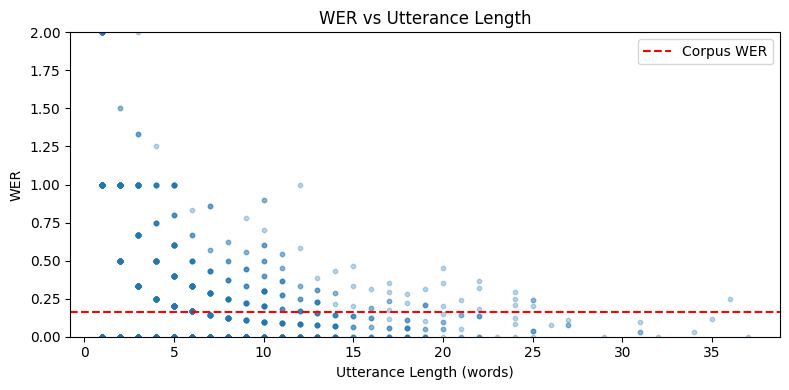

In [16]:
import matplotlib.pyplot as plt

df_all["utt_length_words"] = df_all["real_data_norm"].str.split().str.len()

plt.figure(figsize=(8,4))
plt.scatter(df_all["utt_length_words"], df_all["utt_wer"], alpha=0.3, s=10)
plt.xlabel("Utterance Length (words)")
plt.ylabel("WER")
plt.title("WER vs Utterance Length")
plt.ylim(0, 2)
plt.axhline(df_all["edits"].sum()/df_all["ref_words"].sum(), color="red", linestyle="--", label="Corpus WER")
plt.legend()
plt.tight_layout()
plt.savefig("wer_vs_length.png", dpi=150)
plt.show()

In [17]:
# Look at the 20 worst utterances to identify systematic error patterns
worst = df_all.nlargest(20, "utt_wer")[["Spkr","real_data","Canary_response","utt_wer","subs","dels","ins"]]
pd.set_option("display.max_colwidth", 80)
worst

,Spkr,real_data,Canary_response,utt_wer,subs,dels,ins
1331,ATL_se0_ag1_m_03,c-,there's a lot of stuff,5.0,1,0,4
304,ATL_se0_ag1_f_02,"J-A-W-N,",j a w n,4.0,1,0,3
629,ATL_se0_ag1_f_03,What?,there's no need to,4.0,1,0,3
1183,ATL_se0_ag1_m_02,o-,there's no need to,4.0,1,0,3
298,ATL_se0_ag1_f_02,m-,you know what,3.0,1,0,2
760,ATL_se0_ag1_m_01,It-,you know what,3.0,1,0,2
768,ATL_se0_ag1_m_01,y-,you know what,3.0,1,0,2
1294,ATL_se0_ag1_m_02,P-H-O.,p h o,3.0,1,0,2
5,ATL_se0_ag1_f_01,Ninety-five.,ninety five,2.0,1,0,1
48,ATL_se0_ag1_f_01,Yep.,you know,2.0,1,0,1


In [18]:
df_speaker_errors = (
    df_all.groupby("Spkr")
    .apply(lambda g: pd.Series({
        "n_utterances" : len(g),
        "wer"          : g["edits"].sum() / g["ref_words"].sum(),
        "sub_rate"     : g["subs"].sum() / g["ref_words"].sum(),
        "del_rate"     : g["dels"].sum() / g["ref_words"].sum(),
        "ins_rate"     : g["ins"].sum() / g["ref_words"].sum(),
        "ser"          : g["has_error"].mean(),
    }))
    .reset_index()
    .sort_values("wer", ascending=False)
)

print(df_speaker_errors.to_string(index=False))

            Spkr  n_utterances      wer  sub_rate  del_rate  ins_rate      ser
ATL_se0_ag1_m_01         316.0 0.251859  0.169063  0.059494  0.023302 0.642405
ATL_se0_ag1_f_01         187.0 0.207035  0.141709  0.042211  0.023116 0.566845
ATL_se0_ag1_m_04         114.0 0.168649  0.104865  0.043243  0.020541 0.570175
ATL_se0_ag1_m_02         299.0 0.147423  0.096543  0.035877  0.015003 0.438127
ATL_se0_ag1_m_03         231.0 0.138824  0.090196  0.028235  0.020392 0.393939
ATL_se0_ag1_f_02         292.0 0.127222  0.085556  0.021111  0.020556 0.404110
ATL_se0_ag1_f_03         228.0 0.106218  0.072539  0.016839  0.016839 0.399123


/tmp/ipython-input-149/4172252379.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [19]:
df_all.to_csv("canary_results_full.csv", index=False)
df_speaker_wer.to_csv("canary_wer_by_speaker.csv", index=False)
df_speaker_errors.to_csv("canary_errors_by_speaker.csv", index=False)

from google.colab import files
files.download("canary_results_full.csv")
files.download("canary_wer_by_speaker.csv")
files.download("canary_errors_by_speaker.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>